# Architecting Knowledge Assistants — Hands-on lab (Build 05)

**Routing · Memory · GraphRAG — From Theory to Working Code**  
Brainster **AIatWork** · April 2026 · Maio Labs

**Speaker:** Rui Machado — [maiolabs.ai](https://maiolabs.ai)

---

This notebook is **Build 05** — *Architecting Knowledge Assistants*: **one notebook, three connected systems** — **Part A** (router), **Part B** (memory), **Part C** (GraphRAG / LightRAG). The course introduction covers the architecture gap (naive RAG vs knowledge system), **local vs global** modes, production cases, and the **Karpathy pattern**; here you implement the **LightRAG** surface and the **routing decision inside GraphRAG** (`QueryParam(mode="local" | "global")`).

**Five-box architecture:** (1) Router → (2) Retrieval (RAG, graph, live data you add) → (3) Context assembly → (4) Generate + validate → (5) Memory. This lab implements **graph retrieval + generation** in LightRAG; **world memory** can write back into the graph via ingestion.

**Karpathy pattern:** a folder of `.md` files, **LLM as librarian**, human-readable artifacts, minimal infrastructure — this lab uses the same idea with **`.env`**, **`WORKING_DIR`**, and your **corpus** as the owned bytes.

---

## What you will build

| | RAG 101 | What you will build |
|---|---------|---------------------|
| **Retrieval** | One vector store — everything | Router → multiple surfaces → right tool; **here:** LightRAG + explicit `mode` |
| **Reasoning** | Chunk similarity only | Multi-hop over a **knowledge graph** |
| **Memory** | Stateless | Session + user + world (writes back) — **Part B** maps to patterns + `WORKING_DIR` |
| **Questions** | Factual, single-document | Relational, thematic, cross-document |

---

## Lab stack (what this notebook runs)

| Piece | Role |
|---|---|
| **`lightrag-hku`** | GraphRAG engine: ingest, entity graph, local / global query |
| **LLM** (`LIGHTRAG_PROVIDER`: **openai** / **claudecli** / **ollama**) | Extraction, summaries, answers — from **`.env`** |
| **Embeddings** (`EMBEDDING_BACKEND` + env) | Vectors for chunks / retrieval paths inside LightRAG |
| **`python-dotenv`**, **`.env`** | Secrets and switches without hard-coding keys |
| **NetworkX + GraphML** | Inspect the entity graph LightRAG writes under **`WORKING_DIR`** |
| **matplotlib** | Optional plot in Section 8 |
| **Jupyter / VS Code** | Run cells top to bottom |

### Lab architecture (this notebook)

Most Jupyter front ends **do not render** fenced ` ```mermaid ` blocks (they stay as source). The figure below is the same diagram as an **SVG image** ([mermaid.ink](https://mermaid.ink)); you can also paste the source into [Mermaid Live Editor](https://mermaid.live).

![Lab architecture (this notebook)](https://mermaid.ink/svg/eyJjb2RlIjoiZmxvd2NoYXJ0IFRCXG4gIHN1YmdyYXBoIGVudltcIkNvbmZpZ1wiXVxuICAgIERPVFtcInB5dGhvbi1kb3RlbnZcIl1cbiAgICBFTlZGSUxFW1wiLmVudlwiXVxuICAgIERPVCAtLT4gRU5WRklMRVxuICBlbmRcblxuICBzdWJncmFwaCBwcm92aWRlcnNbXCJNb2RlbCBwcm92aWRlcnMgXHUwMGI3IGZyb20gLmVudlwiXVxuICAgIExMTVtcIkxMTSBcdTAwYjcgTElHSFRSQUdfUFJPVklERVJcXG5vcGVuYWkgXHUwMGI3IGNsYXVkZWNsaSBcdTAwYjcgb2xsYW1hXCJdXG4gICAgRU1CW1wiRW1iZWRkaW5ncyBcdTAwYjcgRU1CRURESU5HX0JBQ0tFTkRcXG5vcGVuYWkgXHUwMGI3IHZveWFnZSBcdTAwYjcgb2xsYW1hXCJdXG4gIGVuZFxuXG4gIHN1YmdyYXBoIGVuZ2luZVtcIkdyYXBoUkFHIGVuZ2luZVwiXVxuICAgIExIS1tcImxpZ2h0cmFnLWhrdSAvIExpZ2h0UkFHXCJdXG4gIGVuZFxuXG4gIENPUlBbXCJDb3JwdXMgdGV4dFwiXVxuICBXRFsoXCJXT1JLSU5HX0RJUlxcbmdyYXBoIFx1MDBiNyB2ZWN0b3JzIFx1MDBiNyBLVlwiKV1cbiAgTlhbXCJOZXR3b3JrWCArIEdyYXBoTUxcXG5TZWN0aW9ucyA3XHUyMDEzOFwiXVxuICBNUExbXCJtYXRwbG90bGliXFxub3B0aW9uYWwgXHUwMGI3IFNlY3Rpb24gOFwiXVxuXG4gIEVOVkZJTEUgLS0-IExMTVxuICBFTlZGSUxFIC0tPiBFTUJcbiAgRU5WRklMRSAtLT4gTEhLXG4gIExMTSAtLT4gTEhLXG4gIEVNQiAtLT4gTEhLXG4gIENPUlAgLS0-fFwiYWluc2VydCAvIGFxdWVyeVwifCBMSEtcbiAgTEhLIC0tPiBXRFxuICBXRCAtLT4gTlhcbiAgV0QgLS4tPiBNUEwifQ)

**Mermaid source** (copy into [mermaid.live](https://mermaid.live); use a ` ```mermaid ` fence there):

```text
flowchart TB
  subgraph env["Config"]
    DOT["python-dotenv"]
    ENVFILE[".env"]
    DOT --> ENVFILE
  end

  subgraph providers["Model providers · from .env"]
    LLM["LLM · LIGHTRAG_PROVIDER\nopenai · claudecli · ollama"]
    EMB["Embeddings · EMBEDDING_BACKEND\nopenai · voyage · ollama"]
  end

  subgraph engine["GraphRAG engine"]
    LHK["lightrag-hku / LightRAG"]
  end

  CORP["Corpus text"]
  WD[("WORKING_DIR\ngraph · vectors · KV")]
  NX["NetworkX + GraphML\nSections 7–8"]
  MPL["matplotlib\noptional · Section 8"]

  ENVFILE --> LLM
  ENVFILE --> EMB
  ENVFILE --> LHK
  LLM --> LHK
  EMB --> LHK
  CORP -->|"ainsert / aquery"| LHK
  LHK --> WD
  WD --> NX
  WD -.-> MPL
```

**Executable scope.** **Part C** end-to-end (install → configure → ingest → **local** / **global** queries → inspect graph). **Part A** includes a **keyword** router and an **LLM** router (same four route *names*). **Part B** is explained and tied to persistence, `ainsert`, and optional incremental docs.

---

## Configuration

Secrets and **`LIGHTRAG_PROVIDER`** (`openai`, `claudecli`, `ollama`) live in **`.env`**. Copy **`.env.example`** → **`.env`**, edit values, run Section 1. **`.env` is gitignored.**

For **`claudecli`**, the model is reached via Anthropic’s service under the hood; this notebook drives it through the **Claude Code** CLI (`claude -p`), not the Anthropic Python SDK. For **fully local** LLM + embeddings, use **`LIGHTRAG_PROVIDER=ollama`**.

---

**Estimated time:** 20–30 minutes (including ingestion)


---
## Section 0 — Installation

Use **`.env`** for every secret and for **`LIGHTRAG_PROVIDER`**. Copy `.env.example` to `.env` before running Section 1. Never paste API keys into notebook cells.

Run the **install** cell next, then **Section 1** (so `rag` exists). **Build 05 — Part A & B** (keyword router + LLM router + Part B table) comes **after** Section 1 in this notebook. From the repo root, **`./setup.sh`** creates **`.venv`**, installs dependencies, and registers a Jupyter kernel **`Python (brainster-lightrag)`**. Activate with `source .venv/bin/activate` (or pick that interpreter in Cursor).


In [37]:
# Part C — step 01 (install lightrag-hku + API clients): pip install lightrag-hku (+ OpenAI client for API paths).
# Full venv: repo ./setup.sh. On Colab, kernel may restart — re-run cells below.
%pip install lightrag-hku openai python-dotenv --quiet
# If .env sets EMBEDDING_BACKEND=voyage:  %pip install voyageai --quiet


Note: you may need to restart the kernel to use updated packages.


---
### Configure LightRAG from `.env` (Part C — step 01 continued)

**The engine:** LightRAG — GraphRAG without the complexity.

1. One line to install — `lightrag-hku` (no Neo4j, no Docker; runs in Colab or locally).
2. **~10× fewer tokens** than Microsoft GraphRAG at two-level retrieval (HKUST, Oct 2024).
3. **Graph storage** — default in-process graph + vectors; LightRAG supports other backends via config (see package README).
4. **Local + global out of the box** — same API, `QueryParam(mode="local" | "global")`.

**Steps in this section**

1. Copy `.env.example` → `.env` and fill in values (`cp .env.example .env`). `.env` is gitignored.
2. Set **`LIGHTRAG_PROVIDER`** to `openai`, `claudecli`, or `ollama`.
3. Run this cell once. It loads `.env`, creates **`WORKING_DIR`** and **`rag`**, then runs **`await rag.initialize_storages()`** (required by current `lightrag-hku` before ingest or query).


In [1]:
# ---
# Section 1 — Part C: initialise LightRAG (install + working_dir + llm + embedding_func).
# - `load_dotenv(...)` — secrets stay out of the notebook.
# - `WORKING_DIR` — persistence root (Part B / world writes back via re-ingest; see Section 3b).
# - `PROVIDER` — OpenAI API vs Claude Code CLI vs Ollama for the LLM.
# ---

import os
import asyncio
import json
import shlex
import shutil
from functools import partial
from pathlib import Path

from dotenv import load_dotenv
from lightrag import LightRAG
from lightrag.utils import EmbeddingFunc

# ── Load .env (never store secrets in the notebook) ────────────────────────────
_env = Path(os.getenv("LIGHTRAG_ENV_FILE", ".env")).expanduser()
if not _env.is_absolute():
    _env = Path.cwd() / _env
load_dotenv(_env, override=False)
print(f"Env file: {_env} (exists={_env.exists()})")

PROVIDER = os.getenv("LIGHTRAG_PROVIDER", "openai").strip().lower()
if PROVIDER not in ("openai", "claudecli", "ollama"):
    raise ValueError(
        "LIGHTRAG_PROVIDER must be one of: openai | claudecli | ollama "
        f"(got {PROVIDER!r})"
    )

EMBED_BACKEND = os.getenv("EMBEDDING_BACKEND", "openai").strip().lower()
if PROVIDER == "ollama":
    pass  # full stack Ollama; embedding path uses OLLAMA_* regardless of EMBEDDING_BACKEND label
elif EMBED_BACKEND not in ("openai", "voyage", "ollama"):
    raise ValueError("EMBEDDING_BACKEND must be openai | voyage | ollama")


def _bool_env(name: str, default: bool = False) -> bool:
    v = os.getenv(name)
    if v is None or v.strip() == "":
        return default
    return v.strip().lower() in ("1", "true", "yes", "on")


def _default_working_dir() -> str:
    wd = (os.getenv("LIGHTRAG_WORKING_DIR") or "").strip()
    if wd:
        return wd
    return {
        "openai": "./rag_storage",
        "claudecli": "./rag_storage_claude_code",
        "ollama": "./rag_storage_local",
    }[PROVIDER]


WORKING_DIR = _default_working_dir()
os.makedirs(WORKING_DIR, exist_ok=True)
print(f"LIGHTRAG_PROVIDER={PROVIDER!r}  WORKING_DIR={WORKING_DIR!r}")


def _resolve_claude_executable() -> str:
    name = os.getenv("CLAUDE_CODE_BIN", "claude")
    if os.path.isfile(name):
        return name
    found = shutil.which(name)
    if found:
        return found
    raise EnvironmentError(
        f"Claude Code CLI not found ({name!r}). Install Claude Code or set CLAUDE_CODE_BIN."
    )


def _format_turn_for_stdin(system_prompt, history_messages, prompt: str) -> str:
    blocks = []
    if system_prompt:
        blocks.append(f"[system]\n{system_prompt}\n")
    for msg in history_messages or []:
        role = msg.get("role", "user")
        content = msg.get("content", "")
        if isinstance(content, list):
            content = "\n".join(str(part) for part in content)
        blocks.append(f"[{role}]\n{content}\n")
    blocks.append(f"[user]\n{prompt}\n")
    return "\n".join(blocks)


def _build_claude_code_llm_func():
    claude_cmd = _resolve_claude_executable()
    timeout_sec = int(os.getenv("CLAUDE_CODE_TIMEOUT_SEC", "600"))
    use_bare = _bool_env("CLAUDE_CODE_BARE")
    cli_cwd = (os.getenv("CLAUDE_CODE_CWD") or "").strip() or os.getcwd()
    extra = shlex.split(os.getenv("CLAUDE_CODE_EXTRA_ARGS", ""))

    async def claude_code_cli_complete(
        prompt: str,
        system_prompt=None,
        history_messages=None,
        enable_cot: bool = False,
        keyword_extraction=False,
        **kwargs,
    ) -> str:
        if history_messages is None:
            history_messages = []
        stdin_payload = _format_turn_for_stdin(system_prompt, history_messages, prompt)
        argv = [
            claude_cmd,
            "-p",
            (
                "You are helping a LightRAG / GraphRAG pipeline. The full turn "
                "(system, prior messages, current user message) is on stdin as plain text. "
                "Answer with the final assistant text only — no markdown fences unless the task asks for code."
            ),
            "--output-format",
            "json",
        ]
        if use_bare:
            argv.append("--bare")
        if extra:
            argv.extend(extra)

        proc = await asyncio.create_subprocess_exec(
            *argv,
            stdin=asyncio.subprocess.PIPE,
            stdout=asyncio.subprocess.PIPE,
            stderr=asyncio.subprocess.PIPE,
            cwd=cli_cwd,
            env=os.environ.copy(),
        )
        try:
            out, err = await asyncio.wait_for(
                proc.communicate(stdin_payload.encode("utf-8")),
                timeout=timeout_sec,
            )
        except asyncio.TimeoutError:
            proc.kill()
            raise RuntimeError(f"claude CLI timed out after {timeout_sec}s") from None

        err_txt = (err or b"").decode("utf-8", errors="replace")
        if proc.returncode != 0:
            raise RuntimeError(
                f"claude exited with code {proc.returncode}. stderr (truncated):\n{err_txt[:8000]}"
            )

        raw = (out or b"").decode("utf-8", errors="replace").strip()
        if not raw:
            raise RuntimeError(f"claude returned empty stdout. stderr:\n{err_txt[:8000]}")
        try:
            payload = json.loads(raw)
        except json.JSONDecodeError:
            payload = json.loads(raw.splitlines()[-1])
        text = payload.get("result")
        if text is None:
            raise RuntimeError(f"claude JSON missing 'result'. Keys: {list(payload.keys())}")
        return text if isinstance(text, str) else json.dumps(text)

    return claude_code_cli_complete


def _embedding_openai():
    from lightrag.llm.openai import openai_embed

    key = os.getenv("OPENAI_API_KEY")
    if not key:
        raise EnvironmentError("OPENAI_API_KEY is required for EMBEDDING_BACKEND=openai")
    model = os.getenv("OPENAI_EMBEDDING_MODEL", "text-embedding-3-small")
    dim = int(os.getenv("OPENAI_EMBEDDING_DIM", "1536"))
    max_tok = int(os.getenv("OPENAI_EMBEDDING_MAX_TOKENS", "8192"))
    return EmbeddingFunc(
        embedding_dim=dim,
        max_token_size=max_tok,
        func=partial(openai_embed.func, model=model, api_key=key),
    )


def _embedding_voyage():
    from lightrag.llm.anthropic import anthropic_embed

    key = os.getenv("VOYAGE_API_KEY")
    if not key:
        raise EnvironmentError("VOYAGE_API_KEY is required for EMBEDDING_BACKEND=voyage")
    model = os.getenv("VOYAGE_EMBEDDING_MODEL", "voyage-3")
    dim = int(os.getenv("VOYAGE_EMBEDDING_DIM", "1024"))
    max_tok = int(os.getenv("VOYAGE_EMBEDDING_MAX_TOKENS", "8192"))
    return EmbeddingFunc(
        embedding_dim=dim,
        max_token_size=max_tok,
        func=lambda texts: anthropic_embed(texts, model=model, api_key=key),
    )


def _embedding_ollama():
    """Local embedding model via Ollama HTTP API (no OpenAI / Voyage keys)."""
    from lightrag.llm.ollama import ollama_embed

    host = os.getenv("OLLAMA_HOST", "http://localhost:11434")
    embed_name = os.getenv("OLLAMA_EMBED_MODEL", "nomic-embed-text")
    dim = int(os.getenv("OLLAMA_EMBEDDING_DIM", "768"))
    max_tok = int(os.getenv("OLLAMA_EMBEDDING_MAX_TOKENS", "8192"))
    # Use ollama_embed.func — the decorated ollama_embed is its own EmbeddingFunc (default dim 1024);
    # calling it inside another EmbeddingFunc causes dimension mismatch (see LightRAG utils docstring).
    return EmbeddingFunc(
        embedding_dim=dim,
        max_token_size=max_tok,
        func=partial(ollama_embed.func, embed_model=embed_name, host=host),
    )


def _embedding_for_provider():
    if PROVIDER == "ollama":
        return _embedding_ollama()
    if EMBED_BACKEND == "ollama":
        return _embedding_ollama()
    if EMBED_BACKEND == "voyage":
        return _embedding_voyage()
    return _embedding_openai()


# ── Build LightRAG ──────────────────────────────────────────────────────────────
if PROVIDER == "openai":
    from lightrag.llm.openai import openai_complete

    if not os.getenv("OPENAI_API_KEY"):
        raise EnvironmentError("OPENAI_API_KEY is required when LIGHTRAG_PROVIDER=openai")
    chat_model = os.getenv("OPENAI_CHAT_MODEL", "gpt-4o-mini")
    rag = LightRAG(
        working_dir=WORKING_DIR,
        llm_model_func=openai_complete,
        llm_model_name=chat_model,
        embedding_func=_embedding_for_provider(),
    )
    print(f"[ok] LightRAG (OpenAI LLM + embeddings): chat={chat_model!r} embed_backend={EMBED_BACKEND!r}")

elif PROVIDER == "claudecli":
    llm_fn = _build_claude_code_llm_func()
    if EMBED_BACKEND == "openai" and not os.getenv("OPENAI_API_KEY"):
        raise EnvironmentError(
            "OPENAI_API_KEY is required when LIGHTRAG_PROVIDER=claudecli and EMBEDDING_BACKEND=openai"
        )
    if EMBED_BACKEND == "voyage" and not os.getenv("VOYAGE_API_KEY"):
        raise EnvironmentError(
            "VOYAGE_API_KEY is required when LIGHTRAG_PROVIDER=claudecli and EMBEDDING_BACKEND=voyage"
        )
    if EMBED_BACKEND == "ollama":
        print(
            "   Embeddings: Ollama (local). Ensure `ollama serve` is running and `ollama pull "
            + (os.getenv("OLLAMA_EMBED_MODEL") or "nomic-embed-text")
            + "` completed."
        )
    rag = LightRAG(
        working_dir=WORKING_DIR,
        llm_model_func=llm_fn,
        llm_model_name="claude-code-cli",
        embedding_func=_embedding_for_provider(),
    )
    print(f"[ok] LightRAG (Claude Code CLI + {EMBED_BACKEND} embeddings)")
    if _bool_env("CLAUDE_CODE_BARE"):
        print("   Note: CLAUDE_CODE_BARE=1 → --bare; Anthropic docs often expect ANTHROPIC_API_KEY for that mode.")

else:  # ollama
    from lightrag.llm.ollama import ollama_model_complete

    host = os.getenv("OLLAMA_HOST", "http://localhost:11434")
    llm_name = os.getenv("OLLAMA_LLM_MODEL", "llama3.2")
    num_ctx = int(os.getenv("OLLAMA_NUM_CTX", "32768"))
    rag = LightRAG(
        working_dir=WORKING_DIR,
        llm_model_func=ollama_model_complete,
        llm_model_name=llm_name,
        llm_model_kwargs={"host": host, "options": {"num_ctx": num_ctx}},
        embedding_func=_embedding_for_provider(),
    )
    print(f"[ok] LightRAG (Ollama): LLM={llm_name!r} host={host!r}")

# Current lightrag-hku requires explicit storage init before ainsert / aquery.
await rag.initialize_storages()
print("[ok] LightRAG storages initialized")


Env file: /Users/ruimachado/Code/brainster/.env (exists=True)
LIGHTRAG_PROVIDER='claudecli'  WORKING_DIR='./rag_storage_claude_code'
   Embeddings: Ollama (local). Ensure `ollama serve` is running and `ollama pull nomic-embed-text` completed.


INFO: [] Loaded graph from ./rag_storage_claude_code/graph_chunk_entity_relation.graphml with 32 nodes, 45 edges
INFO:nano-vectordb:Load (32, 768) data
INFO:nano-vectordb:Init {'embedding_dim': 768, 'metric': 'cosine', 'storage_file': './rag_storage_claude_code/vdb_entities.json'} 32 data
INFO:nano-vectordb:Load (45, 768) data
INFO:nano-vectordb:Init {'embedding_dim': 768, 'metric': 'cosine', 'storage_file': './rag_storage_claude_code/vdb_relationships.json'} 45 data
INFO:nano-vectordb:Load (2, 768) data
INFO:nano-vectordb:Init {'embedding_dim': 768, 'metric': 'cosine', 'storage_file': './rag_storage_claude_code/vdb_chunks.json'} 2 data
INFO: [] Process 99170 KV load full_docs with 2 records
INFO: [] Process 99170 KV load text_chunks with 2 records
INFO: [] Process 99170 KV load full_entities with 2 records
INFO: [] Process 99170 KV load full_relations with 2 records
INFO: [] Process 99170 KV load entity_chunks with 32 records
INFO: [] Process 99170 KV load relation_chunks with 45 reco

[ok] LightRAG (Claude Code CLI + ollama embeddings)
[ok] LightRAG storages initialized


---
## Section 1 — Routing

###  The routing decision *inside* GraphRAG

**In the notebook: the question still decides.** After Part A sends a question to **`graphrag_query`**, LightRAG chooses **how** to retrieve:

| Question shape | → | `QueryParam.mode` | Retrieval idea |
|---|---|---|---|
| Specific entity / relationship (“Who owns Apollo?”, “What links GlobalBank to the AI Act?”) | → | **`local`** | Entity traversal — subgraph |
| Thematic / synthesis (“main risk themes”, “patterns across contracts”) | → | **`global`** | Community summaries — Leiden clusters |

**This section’s `mode` table** (explicit knob — production often sets it from the router + intent):

| `mode` | Primary substrate | Typical question shape |
|---|---|---|
| `local` | Entity-linked **subgraph** + local context | “Who is responsible for…?”, “What links A to B?” |
| `global` | **Community summaries** from ingest | “What are the main themes / risks?” |
| `hybrid` | Local + global merged | Needs both detail and corpus-level synthesis |
| `naive` | **Vector chunks only** (graph unused) | Baseline RAG — “vector RAG retrieves, it does not reason” |

The next cell draws a **pedagogical** figure: your chosen `mode` → retrieval substrate (not LightRAG’s full internal call graph).

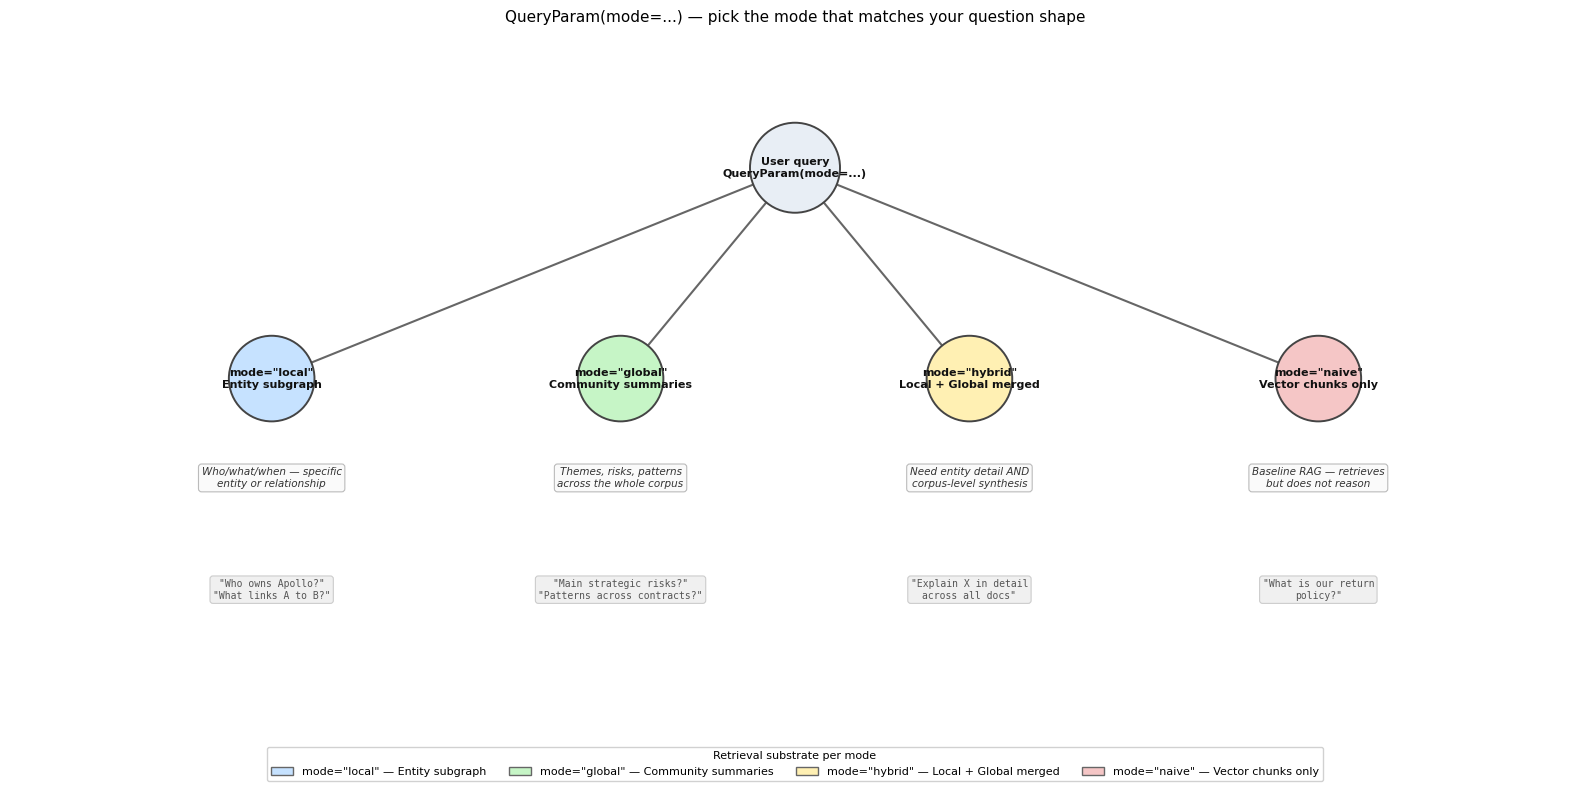

Saved figure: query_routing_graph.png


In [2]:
# Conceptual diagram: user-selected mode -> retrieval substrate (teaching figure).
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import networkx as nx

# ── Mode metadata ─────────────────────────────────────────────────────────────
MODES = [
    {
        "mode": "local",
        "substrate": "Entity subgraph",
        "desc": "Traverses entity\nneighborhood",
        "use_when": "Who/what/when — specific\nentity or relationship",
        "example": '"Who owns Apollo?"\n"What links A to B?"',
        "color": "#c6e2ff",
        "x": -3.0,
    },
    {
        "mode": "global",
        "substrate": "Community summaries",
        "desc": "Leiden clusters\nfrom ingest",
        "use_when": "Themes, risks, patterns\nacross the whole corpus",
        "example": '"Main strategic risks?"\n"Patterns across contracts?"',
        "color": "#c6f5c6",
        "x": -1.0,
    },
    {
        "mode": "hybrid",
        "substrate": "Local + Global merged",
        "desc": "Both paths,\ncombined context",
        "use_when": "Need entity detail AND\ncorpus-level synthesis",
        "example": '"Explain X in detail\nacross all docs"',
        "color": "#fff0b3",
        "x": 1.0,
    },
    {
        "mode": "naive",
        "substrate": "Vector chunks only",
        "desc": "Similarity search,\ngraph unused",
        "use_when": "Baseline RAG — retrieves\nbut does not reason",
        "example": '"What is our return\npolicy?"',
        "color": "#f5c6c6",
        "x": 3.0,
    },
]

ROOT = "User query\nQueryParam(mode=...)"
G = nx.DiGraph()
G.add_node(ROOT)
for m in MODES:
    label = f'mode="{m["mode"]}"\n{m["substrate"]}'
    G.add_node(label)
    G.add_edge(ROOT, label)

pos = {ROOT: (0, 1.0)}
node_labels = {ROOT: ROOT}
node_colors_map = {ROOT: "#e8eef5"}
for m in MODES:
    label = f'mode="{m["mode"]}"\n{m["substrate"]}'
    pos[label] = (m["x"], 0)
    node_labels[label] = label
    node_colors_map[label] = m["color"]

nodes = list(G.nodes())
node_colors = [node_colors_map[n] for n in nodes]
node_sizes  = [4200 if n == ROOT else 3800 for n in nodes]

fig, ax = plt.subplots(figsize=(16, 8))
ax.set_xlim(-4.5, 4.5)
ax.set_ylim(-1.9, 1.6)
ax.axis("off")

nx.draw_networkx_nodes(G, pos, ax=ax, nodelist=nodes,
                       node_size=node_sizes, node_color=node_colors,
                       edgecolors="#444", linewidths=1.4)
nx.draw_networkx_edges(G, pos, ax=ax, arrows=True, arrowsize=16,
                       edge_color="#666", width=1.5)
nx.draw_networkx_labels(G, pos, labels=node_labels, ax=ax,
                        font_size=8, font_color="#111", font_weight="bold")

# ── Annotation boxes below each mode node ─────────────────────────────────────
for m in MODES:
    x = m["x"]
    ax.text(x, -0.42, m["use_when"],
            ha="center", va="top", fontsize=7.5, color="#333",
            style="italic",
            bbox=dict(boxstyle="round,pad=0.3", fc="#fafafa", ec="#bbb", lw=0.8))
    ax.text(x, -0.95, m["example"],
            ha="center", va="top", fontsize=7, color="#555",
            family="monospace",
            bbox=dict(boxstyle="round,pad=0.3", fc="#f0f0f0", ec="#ccc", lw=0.8))

# ── Legend ─────────────────────────────────────────────────────────────────────
legend_handles = [
    mpatches.Patch(facecolor=m["color"], edgecolor="#666",
                   label=f'mode="{m["mode"]}" — {m["substrate"]}')
    for m in MODES
]
ax.legend(handles=legend_handles, loc="lower center",
          bbox_to_anchor=(0.5, -0.01), ncol=4,
          fontsize=8, framealpha=0.9,
          title="Retrieval substrate per mode", title_fontsize=8)

ax.set_title(
    "QueryParam(mode=...) — pick the mode that matches your question shape",
    fontsize=11, pad=14,
)

plt.tight_layout()
plt.savefig("query_routing_graph.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved figure: query_routing_graph.png")

### Option A — The static router (one assistant, four paths)

The following four routes use the same *names* a production router would emit before calling tools:

| Example question | Route | Surface in full stack |
|---|---|---|
| "What's our return policy?" | `search_documents` | Vector RAG — e.g. Chroma |
| "What were yesterday's sales?" | `query_sales_data` | SQL — DuckDB |
| "What did Anthropic announce?" | `search_web` | Tavily |
| "What links these 50 contracts?" | `graphrag_query` | LightRAG — often **`mode="global"`** for synthesis |

In production, `router_chain = prompt | llm | StrOutputParser()` returns one of these strings **and you log every decision** (mis-routing wastes tokens and latency).


In [3]:
# Part A — keyword router (same route strings as the table above; log every decision).
# The **LLM router** is in the next two cells (same Part A).
# Replace with LangGraph + `StrOutputParser()` when you wire a full orchestration graph.

ROUTES = (
    "search_documents",
    "query_sales_data",
    "search_web",
    "graphrag_query",
)


def classify_route(question: str) -> str:
    q = question.lower()
    if any(k in q for k in ("sales", "revenue", "kpi", "yesterday", "q3 revenue", "duckdb", "sql")):
        return "query_sales_data"
    if any(k in q for k in ("announce", "news", "anthropic", "tavily", "web", "today")):
        return "search_web"
    if any(
        k in q
        for k in (
            "contracts",
            "50 contract",
            "risk themes",
            "main themes",
            "patterns across",
            "leadership distributed",
            "graphrag",
            "lightrag",
        )
    ):
        return "graphrag_query"
    return "search_documents"


def log_routing_decision(question: str) -> str:
    route = classify_route(question)
    print(f"[router] route={route!r}  question={question[:72]!r}{'...' if len(question) > 72 else ''}")
    return route


# Example questions (routing table)
for demo_q in (
    "What's our return policy?",
    "What were yesterday's sales?",
    "What did Anthropic announce?",
    "What links these 50 contracts?",
):
    log_routing_decision(demo_q)


[router] route='search_documents'  question="What's our return policy?"
[router] route='query_sales_data'  question="What were yesterday's sales?"
[router] route='search_web'  question='What did Anthropic announce?'
[router] route='graphrag_query'  question='What links these 50 contracts?'


### Option B — LLM router (recommended)

**Prerequisite:** Section 1 above finished — `rag` and `rag.llm_model_func` are ready (same provider as the rest of the lab: OpenAI, Claude Code CLI, or Ollama).

The model must answer with **exactly one** of: `search_documents`, `query_sales_data`, `search_web`, `graphrag_query`. The code normalizes stray punctuation or a short rationale.

If the next cell errors, use the **keyword router** in the cell above or fix your `.env` / CLI auth.

In [4]:
# Part A — LLM router (uses the same LLM as LightRAG via rag.llm_model_func)
import re

# Same four route identifiers as the keyword router (kept local so this cell runs standalone).
ROUTES_LLM = (
    "search_documents",
    "query_sales_data",
    "search_web",
    "graphrag_query",
)

ROUTER_SYSTEM = """You are a routing classifier for a knowledge assistant.
Output exactly ONE line containing only one of these four identifiers (lowercase, no quotes, no punctuation):
search_documents
query_sales_data
search_web
graphrag_query

Definitions:
- search_documents — internal policies, FAQs, procedures, handbooks, "what is our return policy".
- query_sales_data — numeric KPIs, revenue, sales, quotas, "yesterday's sales", SQL/warehouse style questions.
- search_web — time-sensitive or public web information, news, press, "what did X announce today".
- graphrag_query — questions over an ingested knowledge graph: entity linkage, contracts, themes across docs, multi-hop org questions.

Examples (output only the identifier):
User: What's our return policy?
Assistant: search_documents
User: What were yesterday's sales?
Assistant: query_sales_data
User: What did Anthropic announce?
Assistant: search_web
User: What links these 50 contracts?
Assistant: graphrag_query
"""

_ALLOWED = frozenset(ROUTES_LLM)


def _normalize_route_llm(raw: str) -> str:
    if not raw or not isinstance(raw, str):
        return "search_documents"
    text = raw.strip().lower()
    m = re.search(
        r"\b(search_documents|query_sales_data|search_web|graphrag_query)\b",
        text,
        flags=re.I,
    )
    if m:
        return m.group(1).lower()
    for tok in re.split(r"[^\w_]+", text):
        if tok.lower() in _ALLOWED:
            return tok.lower()
    return "search_documents"


async def classify_route_llm(question: str) -> str:
    prompt = (
        "Classify the following user question.\n\n"
        f"QUESTION:\n{question}\n\n"
        "Respond with exactly one route identifier on one line."
    )
    out = await rag.llm_model_func(
        prompt,
        system_prompt=ROUTER_SYSTEM,
        history_messages=[],
        keyword_extraction=False,
    )
    if not isinstance(out, str):
        out = str(out)
    return _normalize_route_llm(out)


async def log_routing_decision_llm(question: str) -> str:
    route = await classify_route_llm(question)
    tail = "..." if len(question) > 72 else ""
    print(f"[router-llm] route={route!r}  question={question[:72]!r}{tail}")
    return route


# Same demo questions as the keyword router
for _q in (
    "What's our return policy?",
    "What were yesterday's sales?",
    "What did Anthropic announce?",
    "What links these 50 contracts?",
):
    await log_routing_decision_llm(_q)


INFO: LLM func: 4 new workers initialized (Timeouts: Func: 180s, Worker: 360s, Health Check: 375s)


[router-llm] route='search_documents'  question="What's our return policy?"
[router-llm] route='query_sales_data'  question="What were yesterday's sales?"
[router-llm] route='search_web'  question='What did Anthropic announce?'
[router-llm] route='graphrag_query'  question='What links these 50 contracts?'


---
## Section 2 — Prepare the corpus

You have three options:

**A)** Use the demo text included here (fictional company report)  
**B)** Load your own `.txt` or `.pdf` file  
**C)** Paste text directly into the `CORPUS_TEXT` variable

### Pedagogy: corpus choice
Use a document with **real entities** (people, organizations, dates, events) and **relations among them**. Ideal examples:
- Annual company report
- Board meeting minutes
- A set of contracts
- Scientific paper with multiple authors and cross-references


In [5]:
# Corpus cell: defines CORPUS_TEXT ingested in Section 3.
# Pedagogy: GraphRAG quality depends on explicit entities and relations in the source text.
# The demo report is intentionally dense with names, products, and obligations for teaching.

# ── Option A: Demo corpus ─────────────────────────────────────────────────────
# Fictional TechNova company report for demonstration.
# Contains entities (people, products, events) and relations among them.

DEMO_CORPUS = """
TechNova Annual Strategy Report — Q4 2023

Executive Summary
TechNova, led by CEO Maria Santos and CTO Jorge Ferreira, closed 2023 with revenue of €42M,
a 31% increase over 2022. The board, chaired by António Carvalho, approved a €15M investment
in the Orion product line in January 2024.

Product Developments
The Orion Platform launched in March 2023 under the direction of Product VP Carla Mendes.
It integrates with the legacy Apollo system, which has been in production since 2019.
The Orion team, composed of 12 engineers based in Lisbon and Porto, delivered three major
releases: v1.0 (March), v1.5 (July), and v2.0 (November).

The Apollo system, managed by lead architect Pedro Nunes, was flagged for deprecation in
the Q3 board meeting. António Carvalho instructed the team to maintain Apollo support until
at least Q2 2025 due to contractual obligations with key client GlobalBank.

Key Clients
GlobalBank became TechNova's largest client in 2021, representing 28% of total revenue.
The GlobalBank contract, signed by Maria Santos and GlobalBank CTO David Oliveira, runs
until December 2025. GlobalBank uses both the Apollo and Orion platforms.

RetailCo onboarded in June 2023 exclusively on Orion v1.5. The onboarding was led by
Carla Mendes and RetailCo IT Director Sofia Costa. RetailCo reported a 40% reduction in
data processing time after migration.

Regulatory and Risk
In September 2023, TechNova received a data governance audit request from the Portuguese
Data Protection Authority (CNPD). Jorge Ferreira coordinated the response, which was
submitted in November 2023. The audit covered data flows between the Apollo and Orion
systems, particularly regarding GlobalBank data.

The legal team, headed by General Counsel Ana Rodrigues, flagged three contract clauses
in the GlobalBank agreement as potentially non-compliant with the EU AI Act (Article 13).
Remediation is scheduled for Q1 2024 with input from external counsel Linklaters.

People
Maria Santos joined TechNova in 2018 as VP Engineering before becoming CEO in 2021.
Jorge Ferreira has been CTO since 2019, previously working at Farfetch and at Unbabel.
Carla Mendes was hired from Revolut in early 2023 specifically to lead the Orion launch.
Pedro Nunes is a TechNova founding team member, responsible for Apollo's original architecture.

2024 Priorities
1. Complete Apollo-to-Orion migration for all clients by Q3 2024
2. Resolve EU AI Act compliance gaps in GlobalBank contract (Q1 2024)
3. Expand to Spanish market — led by Jorge Ferreira, targeting 3 enterprise clients
4. Launch Orion v3.0 with embedded ML pipeline, scheduled for May 2024
5. Hire 20 engineers in Lisbon and 5 in Madrid
"""

# ── Option B: Load your own file ───────────────────────────────────────────────
# Uncomment and adjust the path:
# with open("my_document.txt", "r", encoding="utf-8") as f:
#     CORPUS_TEXT = f.read()

# For PDF (requires: pip install pymupdf)
# import fitz  # pymupdf
# doc = fitz.open("report.pdf")
# CORPUS_TEXT = "\n".join(page.get_text() for page in doc)

# ── Select corpus ──────────────────────────────────────────────────────────────
CORPUS_TEXT = DEMO_CORPUS  # replace with loaded CORPUS_TEXT if you used your own file

print(f"Corpus ready: {len(CORPUS_TEXT):,} characters")
print(f"   First 200 chars: {CORPUS_TEXT[:200].strip()}...")


Corpus ready: 2,678 characters
   First 200 chars: TechNova Annual Strategy Report — Q4 2023

Executive Summary
TechNova, led by CEO Maria Santos and CTO Jorge Ferreira, closed 2023 with revenue of €42M,
a 31% increase over 2022. The board, chaired b...


---
## Section 3 — Ingestion and graph construction (Part C — step 02)

**Part C:** `await rag.ainsert(...)` — extracts entities, builds the graph, generates **community summaries** for later **global** queries.

**Teaching note.** Ingestion is the expensive phase: the LLM repeatedly reads text chunks and proposes entities (nodes) and relations (edges). LightRAG then clusters entities into *communities* and asks the LLM for short *community summaries*. Those summaries are the substrate for **global** queries later.

This is the slowest step. What happens internally:

1. **Chunking** — text is split into overlapping segments.
2. **Entity extraction** — the LLM labels candidate nodes (people, organizations, systems, events).
3. **Relation extraction** — the LLM proposes directed edges (who did what, with whom, when).
4. **Community detection** — related entities are grouped (for global synthesis).
5. **Community summaries** — the LLM writes a compact summary per cluster.
6. **Vector indexing** — chunk embeddings support semantic retrieval (including the `naive` path).

**Estimated time:** roughly 2–5 minutes for the demo corpus (~1,000 words). For tens of pages, expect proportionally longer wall time.


In [6]:
# Ingestion binds the corpus into LightRAG's persistent stores under WORKING_DIR.
# After this cell, Section 3b lists files (memory on disk); Sections 7–8 read the GraphML graph.

import time

print("Starting ingestion...")
print("   The LLM is extracting entities and relations — this may take a few minutes.")
print()

start = time.time()

# Prerequisite: Section 1 ran `await rag.initialize_storages()` after creating `rag`.
await rag.ainsert(CORPUS_TEXT)

elapsed = time.time() - start
print(f"\nIngestion completed in {elapsed:.1f}s")
print(f"Graph artifacts written under: {WORKING_DIR}/")


INFO: Created 1 duplicate document records with track_id: insert_20260422_174222_4bbe7e03
INFO: Preserving 4 failed document entries for manual review
INFO: No valid documents to process after consistency check
INFO: Enqueued document processing pipeline stopped


Starting ingestion...
   The LLM is extracting entities and relations — this may take a few minutes.


Ingestion completed in 0.0s
Graph artifacts written under: ./rag_storage_claude_code/


---
## Section 3b — Part B: persistence and “memory on disk”

**Part B** distinguishes **session**, **user**, and **world** memory. In this lab:

- **Session** — your live kernel state (variables, last queries). For a real app, append turns to `state["session_memory"]` and cap length (e.g. last ~5 exchanges).
- **User** — preferences stored verbatim outside this notebook (never interpret; e.g. `{"role": "CFO", "prefers": "bullets"}`).
- **World** — facts that should live in the shared knowledge base. LightRAG updates the graph when you call **`ainsert`** again (Section 10 shows incremental **world** writes).

LightRAG also **writes durable artifacts** under **`WORKING_DIR`** (Section 1): graph structure, vector indices, JSON/JSONL stores — the **durable substrate** you reload on the next run.

**Teaching points**

- **Working directory** = persistence boundary. Same path + same provider → warm start; new path → cold start.
- **Graph side**: entity–relation graph (often GraphML) — **logical graph database** view (Sections 7–8).
- **Vector side**: chunk embeddings for *naive* / hybrid paths.
- **Filenames** vary by `lightrag-hku` version; listing the folder after ingest grounds the architecture.


In [7]:
# List files under WORKING_DIR after ingestion (LightRAG "memory" on disk).
from pathlib import Path

root = Path(WORKING_DIR)
print(f"WORKING_DIR (resolved): {root.resolve()}")
if not root.exists():
    print("(empty — run Section 3 ingestion first)")
else:
    for p in sorted(root.iterdir()):
        label = "dir" if p.is_dir() else "file"
        if p.is_file():
            sz = p.stat().st_size
            print(f"  {p.name:42} {label:4}  {sz:>12,} bytes")
        else:
            print(f"  {p.name:42} {label}")
    graphml = root / "graph_chunk_entity_relation.graphml"
    if graphml.is_file():
        print(
            "\nGraphML present: this is the exported entity graph used in Sections 7–8 "
            "(NetworkX reads it as the knowledge graph)."
        )


WORKING_DIR (resolved): /Users/ruimachado/Code/brainster/rag_storage_claude_code
  graph_chunk_entity_relation.graphml        file        37,889 bytes
  kv_store_doc_status.json                   file         4,521 bytes
  kv_store_entity_chunks.json                file         6,567 bytes
  kv_store_full_docs.json                    file         3,762 bytes
  kv_store_full_entities.json                file         1,268 bytes
  kv_store_full_relations.json               file         3,399 bytes
  kv_store_llm_response_cache.json           file       117,587 bytes
  kv_store_relation_chunks.json              file        10,489 bytes
  kv_store_text_chunks.json                  file         4,274 bytes
  vdb_chunks.json                            file        15,934 bytes
  vdb_entities.json                          file       207,806 bytes
  vdb_relationships.json                     file       291,926 bytes

GraphML present: this is the exported entity graph used in Sections 7–8 (Netwo

---
## Section 4 — Local query (Part C — step 03)

**Prerequisite.** Section 4a + ingestion complete. **`mode="local"`** means **entity traversal — subgraph**: anchor on entities in the question, expand along neighbors, answer with grounded detail (e.g. Apollo / GlobalBank / EU AI Act).

**Local query** — traverse specific entities and incident edges, then condition the LLM on that subgraph.

The three runnable questions below mirror the **local** column (TechNova corpus): responsibility for Apollo, GlobalBank ↔ EU AI Act, Carla Mendes hire.

Internally (conceptually):
1. Align the question to graph entities (implementation inside LightRAG).
2. Pull a bounded neighborhood subgraph.
3. Serialize subgraph + chunk evidence into the LLM context.


In [8]:
# ---
# Query helper: explicit routing via LightRAG `QueryParam(mode=...)`.
# This is the API surface students use for the rest of the lab.
# ---
from lightrag import QueryParam


async def query(question: str, mode: str = "local") -> str:
    """Run `rag.aquery` with a fixed retrieval mode (routing knob).

    Student note: LightRAG does not auto-select the mode here — *you* pick it, which mirrors how
    production systems often separate "intent / routing" (upstream) from "retrieval" (this call).

    Modes (see also Section 4a):
    - 'local'  — entity-centric subgraph + local evidence (good for "who / what / when").
    - 'global' — community summaries from ingestion (good for themes across the corpus).
    - 'hybrid' — combines local and global contexts.
    - 'naive'  — vector RAG over chunks; graph structure is not used (baseline).
    """
    return await rag.aquery(question, param=QueryParam(mode=mode))

print("Query helper ready (uses rag.aquery + QueryParam)")


Query helper ready (uses rag.aquery + QueryParam)


In [9]:
# ── Question 1 (worked example — local) ────────────────────────────────────────────
q1 = "Who is responsible for the Apollo system?"

print(f"Question: {q1}")
print("   Mode: local — entity traversal / subgraph")
print("-" * 60)

r1 = await query(q1, mode="local")
print(r1)


INFO: Embedding func: 8 new workers initialized (Timeouts: Func: 30s, Worker: 60s, Health Check: 75s)


Question: Who is responsible for the Apollo system?
   Mode: local — entity traversal / subgraph
------------------------------------------------------------


INFO: Query nodes: Apollo, responsible party, owner, maintainer (top_k:40, cosine:0.2)
INFO: Local query: 32 entites, 45 relations
INFO: Raw search results: 32 entities, 45 relations, 0 vector chunks
INFO: After truncation: 32 entities, 45 relations
INFO: Selecting 2 from 2 entity-related chunks by vector similarity
INFO: Find no additional relations-related chunks from 45 relations
INFO: Round-robin merged chunks: 2 -> 2 (deduplicated 0)
INFO: Final context: 32 entities, 45 relations, 2 chunks
INFO: Final chunks S+F/O: E27/1 E12/2
INFO:  == LLM cache == Query cache hit, using cached response as query result


**Pedro Nunes** is responsible for the Apollo system. He is a TechNova founding team member and serves as the **lead architect** responsible for Apollo's original architecture and its ongoing management.

The Apollo system has been in production since 2019 and was flagged for deprecation in the Q3 board meeting. Despite this, **António Carvalho** (TechNova's board chair) instructed the team to maintain Apollo support until at least **Q2 2025**, due to contractual obligations with GlobalBank.

### References

- [1] TechNova Annual Strategy Report — Q4 2023


In [10]:
# ── Question 2 (worked example — local) ─────────────────────────────────────────────
q2 = "What links GlobalBank to the EU AI Act issue?"

print(f"Question: {q2}")
print("   Mode: local — contract → clause → regulation (multi-hop)")
print("-" * 60)

r2 = await query(q2, mode="local")
print(r2)


INFO: Query nodes: GlobalBank, EU AI Act, compliance issue, AI Act violation (top_k:40, cosine:0.2)
INFO: Local query: 32 entites, 45 relations
INFO: Raw search results: 32 entities, 45 relations, 0 vector chunks
INFO: After truncation: 32 entities, 45 relations
INFO: Selecting 2 from 2 entity-related chunks by vector similarity
INFO: Find no additional relations-related chunks from 45 relations
INFO: Round-robin merged chunks: 2 -> 2 (deduplicated 0)
INFO: Final context: 32 entities, 45 relations, 2 chunks
INFO: Final chunks S+F/O: E12/1 E27/2
INFO:  == LLM cache == Query cache hit, using cached response as query result


Question: What links GlobalBank to the EU AI Act issue?
   Mode: local — contract → clause → regulation (multi-hop)
------------------------------------------------------------
## GlobalBank and the EU AI Act Issue

The connection between GlobalBank and the EU AI Act issue runs through TechNova's contractual and legal review processes.

**The Contract**

GlobalBank is TechNova's largest client since 2021, representing 28% of total revenue. The contract, co-signed by TechNova CEO Maria Santos and GlobalBank CTO David Oliveira, runs until December 2025 and covers use of both the Apollo and Orion platforms.

**The Compliance Flag**

TechNova's General Counsel, **Ana Rodrigues**, reviewed the GlobalBank agreement and flagged **three contract clauses** as potentially non-compliant with **Article 13 of the EU AI Act**. This article relates to transparency obligations for AI systems.

**The Remediation Plan**

Remediation of these non-compliant clauses was scheduled for **Q1 2024**, with supp

In [11]:
# ── Question 3 (worked example — local) ─────────────────────────────────────────────
q3 = "Who hired Carla Mendes and why?"

print(f"Question: {q3}")
print("   Mode: local — board / hiring context → Revolut → Orion launch")
print("-" * 60)

r3 = await query(q3, mode="local")
print(r3)


INFO: Query nodes: Carla Mendes, employer, job offer, hiring reason (top_k:40, cosine:0.2)
INFO: Local query: 32 entites, 45 relations
INFO: Raw search results: 32 entities, 45 relations, 0 vector chunks
INFO: After truncation: 32 entities, 45 relations
INFO: Selecting 2 from 2 entity-related chunks by vector similarity
INFO: Find no additional relations-related chunks from 45 relations
INFO: Round-robin merged chunks: 2 -> 2 (deduplicated 0)
INFO: Final context: 32 entities, 45 relations, 2 chunks
INFO: Final chunks S+F/O: E12/1 E27/2
INFO:  == LLM cache == Query cache hit, using cached response as query result


Question: Who hired Carla Mendes and why?
   Mode: local — board / hiring context → Revolut → Orion launch
------------------------------------------------------------
Based on the provided context, **TechNova hired Carla Mendes** from **Revolut** in **early 2023**, specifically to **lead the launch of the Orion Platform**.

She was brought on as **Product VP** and played a central role in the platform's rollout, including directing the Orion Platform launch in March 2023 and co-leading the onboarding of key client RetailCo alongside RetailCo's IT Director, Sofia Costa.

### References

- [1] TechNova Annual Strategy Report — Q4 2023
- [2] TechNova Press Release — February 2024


---
## Section 5 — Global query (Part C — step 04)

**Global query** — **community summaries — Leiden clusters**: synthesis across communities of entities, not a single chunk.

Best for: “What are the main strategic risks?”, patterns across contracts, leadership distribution — **no single chunk holds the answer**.

The engine uses **community summaries** from ingestion. **Use GraphRAG when**: questions link across documents; global synthesis; explicit relations (contracts, tickets, legal); explainability. **Stick with vector RAG when**: single-document facts; corpus churn; tiny corpus / tight latency; “users just need FAQs”.


In [12]:
# ── Question 4 (worked example — global) ───────────────────────────────────────────
q4 = "What are the main strategic risks at TechNova?"

print(f"Question: {q4}")
print("   Mode: global — community summaries / thematic synthesis")
print("-" * 60)

r4 = await query(q4, mode="global")
print(r4)


INFO: Query edges: Strategic risks, Risk assessment, Corporate strategy (top_k:40, cosine:0.2)
INFO: Global query: 27 entites, 40 relations
INFO: Raw search results: 27 entities, 40 relations, 0 vector chunks
INFO: After truncation: 27 entities, 40 relations
INFO: Selecting 2 from 2 entity-related chunks by vector similarity
INFO: Find no additional relations-related chunks from 40 relations
INFO: Round-robin merged chunks: 2 -> 2 (deduplicated 0)
INFO: Final context: 27 entities, 40 relations, 2 chunks
INFO: Final chunks S+F/O: E10/1 E24/2
INFO:  == LLM cache == Query cache hit, using cached response as query result


Question: What are the main strategic risks at TechNova?
   Mode: global — community summaries / thematic synthesis
------------------------------------------------------------
## Main Strategic Risks at TechNova

Based on the available information, TechNova faces several significant strategic risks across regulatory, operational, and commercial dimensions.

---

### 1. EU AI Act Compliance Risk

TechNova's General Counsel, **Ana Rodrigues**, flagged **three clauses in the GlobalBank contract** as potentially non-compliant with **EU AI Act Article 13**. Remediation is scheduled for Q1 2024, with external counsel **Linklaters** engaged to assist. Failure to resolve these gaps could jeopardize TechNova's most important client relationship and expose the company to regulatory penalties.

---

### 2. Client Concentration Risk

**GlobalBank** represents **28% of total revenue** and is TechNova's largest client since 2021. This heavy dependence on a single client creates significant vulnerab

In [45]:
# ── Question 5 (worked example — global) ────────────────────────────────────────────
q5 = "How is leadership distributed across priorities?"

print(f"Question: {q5}")
print("   Mode: global — cross-entity synthesis")
print("-" * 60)

r5 = await query(q5, mode="global")
print(r5)


INFO: Query edges: Leadership distribution, Organizational priorities, Decision-making structure (top_k:40, cosine:0.2)
INFO: Global query: 26 entites, 40 relations
INFO: Raw search results: 26 entities, 40 relations, 0 vector chunks
INFO: After truncation: 26 entities, 40 relations
INFO: Selecting 2 from 2 entity-related chunks by vector similarity
INFO: Find no additional relations-related chunks from 40 relations
INFO: Round-robin merged chunks: 2 -> 2 (deduplicated 0)
INFO: Final context: 26 entities, 40 relations, 2 chunks
INFO: Final chunks S+F/O: E11/1 E22/2
INFO:  == LLM cache == Query cache hit, using cached response as query result


Question: How is leadership distributed across priorities?
   Mode: global — cross-entity synthesis
------------------------------------------------------------
## Leadership Distribution Across TechNova's 2024 Priorities

TechNova's 2024 strategic priorities are distributed across several key leaders, with responsibilities aligned to their functional roles.

### CEO — Maria Santos
Maria Santos provides overall organizational leadership and is the executive to whom the VP of Sales (Lucas Pereira) reports. She co-signed the GlobalBank contract, making her directly accountable for the relationship that drives the Apollo-to-Orion migration priority and the EU AI Act compliance remediation.

### CTO — Jorge Ferreira
Jorge Ferreira carries significant operational weight across multiple priorities:
- **Spanish market expansion** — he leads this initiative, targeting 3 enterprise clients.
- **CNPD audit response** — he coordinated TechNova's regulatory response submitted in November 2023.
- T

---
## Section 6 — Comparison: GraphRAG vs classic RAG

**Illustrative ranges (MSR 2024 / HKUST 2024):** multi-hop accuracy ~**43–50%** vector RAG vs ~**80–91%** GraphRAG; LightRAG two-level retrieval at **~10×** lower token cost than Microsoft GraphRAG.

Run the same question in **`naive`** (chunks + similarity — “retrieves, does not reason”) vs **`global`** (community synthesis). Compare depth and how well cross-cutting themes hold together.


In [49]:
comparison_question = "What are the main strategic risks at TechNova?"

print("=" * 70)
print(f"QUESTION: {comparison_question}")
print("=" * 70)


print("\nNAIVE RAG (vector — isolated chunks)")
print("-" * 70)
r_naive = await query(comparison_question, mode="naive")
print(r_naive)


print("\nGRAPHRAG GLOBAL (community summaries — knowledge graph path)")
print("-" * 70)
r_global = await query(comparison_question, mode="global")
print(r_global)

print("\n" + "=" * 70)
print("Global mode aggregates themes no single chunk reliably carries.")


INFO: Naive query: 2 chunks (chunk_top_k:20 cosine:0.2)
INFO: Final context: 2 chunks
INFO:  == LLM cache == Query cache hit, using cached response as query result
INFO: Query edges: Strategic risks, Risk assessment, Corporate strategy (top_k:40, cosine:0.2)
INFO: Global query: 27 entites, 40 relations
INFO: Raw search results: 27 entities, 40 relations, 0 vector chunks
INFO: After truncation: 27 entities, 40 relations
INFO: Selecting 2 from 2 entity-related chunks by vector similarity
INFO: Find no additional relations-related chunks from 40 relations
INFO: Round-robin merged chunks: 2 -> 2 (deduplicated 0)
INFO: Final context: 27 entities, 40 relations, 2 chunks
INFO: Final chunks S+F/O: E10/1 E24/2
INFO:  == LLM cache == Query cache hit, using cached response as query result


QUESTION: What are the main strategic risks at TechNova?

NAIVE RAG (vector — isolated chunks)
----------------------------------------------------------------------
## Main Strategic Risks at TechNova

Based on the available documents, several strategic risks stand out for TechNova:

### 1. Legacy System Dependency (Apollo Deprecation)
The Apollo system has been flagged for deprecation, yet TechNova is contractually obligated to maintain it until at least Q2 2025 due to commitments with key client **GlobalBank**. This creates a dual burden: the company must invest in both maintaining a legacy system and accelerating the migration to Orion, straining engineering resources.

### 2. Client Concentration Risk
**GlobalBank** represents **28% of total revenue** — a significant dependency on a single client. Any disruption to that relationship (contractual, regulatory, or technical) could have a material impact on TechNova's financial performance. The contract runs until December 2025, limit

---
## Section 7 — Inspect the graph store (entity graph on disk)

**Conceptual distinction (exam-style).**

- **Query routing graph** (Section 4a): a *pedagogical* diagram of how `QueryParam(mode=...)` selects retrieval logic. It is saved as `query_routing_graph.png` when you run that cell.
- **Knowledge graph / graph store** (this section): the *data* LightRAG extracted — exported here as GraphML (`graph_chunk_entity_relation.graphml` under `WORKING_DIR`). Treat it as the logical “graph database” view of your corpus for this lab configuration.

The code below loads GraphML with NetworkX and prints simple graph statistics so students can connect quantitative structure (degree, density) to qualitative answers from Section 4–5.


In [13]:
import os
import networkx as nx

# ── Locate graph file ─────────────────────────────────────────────────────────
graph_file = os.path.join(WORKING_DIR, "graph_chunk_entity_relation.graphml")

if not os.path.exists(graph_file):
    print(f"[WARN] File not found at {graph_file}")
    print("   Check that ingestion (Section 3) completed successfully.")
else:
    G = nx.read_graphml(graph_file)
    
    print("GRAPH STATISTICS")
    print("-" * 40)
    print(f"  Nodes (entities):   {G.number_of_nodes():>6}")
    print(f"  Edges (relations): {G.number_of_edges():>6}")
    print(f"  Density:          {nx.density(G):.4f}")
    print()
    
    # Top 10 entities by degree (most connected)
    degree_sorted = sorted(G.degree(), key=lambda x: x[1], reverse=True)
    print("TOP 10 MOST CONNECTED ENTITIES")
    print("-" * 40)
    for node, degree in degree_sorted[:10]:
        node_type = G.nodes[node].get("entity_type", "?")
        print(f"  {node:<30} degree={degree:<4} type={node_type}")
    print()
    
    # Sample of relations
    print("SAMPLE OF EXTRACTED RELATIONS (first 10)")
    print("-" * 40)
    for i, (u, v, data) in enumerate(G.edges(data=True)):
        if i >= 10:
            break
        rel = data.get("description", data.get("keywords", "related"))
        # Truncate long descriptions
        rel_short = (rel[:70] + "...") if len(str(rel)) > 70 else rel
        print(f"  [{u}] → [{v}]")
        print(f"    -> {rel_short}")


GRAPH STATISTICS
----------------------------------------
  Nodes (entities):       32
  Edges (relations):     45
  Density:          0.0907

TOP 10 MOST CONNECTED ENTITIES
----------------------------------------
  TechNova                       degree=14   type=organization
  Orion Platform                 degree=8    type=artifact
  GlobalBank                     degree=7    type=organization
  Jorge Ferreira                 degree=6    type=person
  Apollo System                  degree=6    type=artifact
  Lucas Pereira                  degree=5    type=person
  RetailCo                       degree=5    type=organization
  Carla Mendes                   degree=5    type=person
  CNPD Audit                     degree=4    type=event
  Maria Santos                   degree=3    type=person

SAMPLE OF EXTRACTED RELATIONS (first 10)
----------------------------------------
  [TechNova] → [Lucas Pereira]
    -> Lucas Pereira was appointed VP of Sales for the Iberian market at Tech...

---
## Section 8 — Plot the entity graph (optional)

This is a **layout visualization** of the same GraphML entity graph (not the routing diagram from Section 4a). For large graphs, prefer exporting GraphML to [Gephi](https://gephi.org) or [Neo4j Bloom](https://neo4j.com/product/bloom/).


Visualizing subgraph: 15 nodes, 29 edges


/var/folders/cx/hkm1s2xd5rb3bwzd4dxk95xr0000gn/T/ipykernel_99170/3184976687.py:33: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  color_map = plt.cm.get_cmap("tab10", len(unique_types))


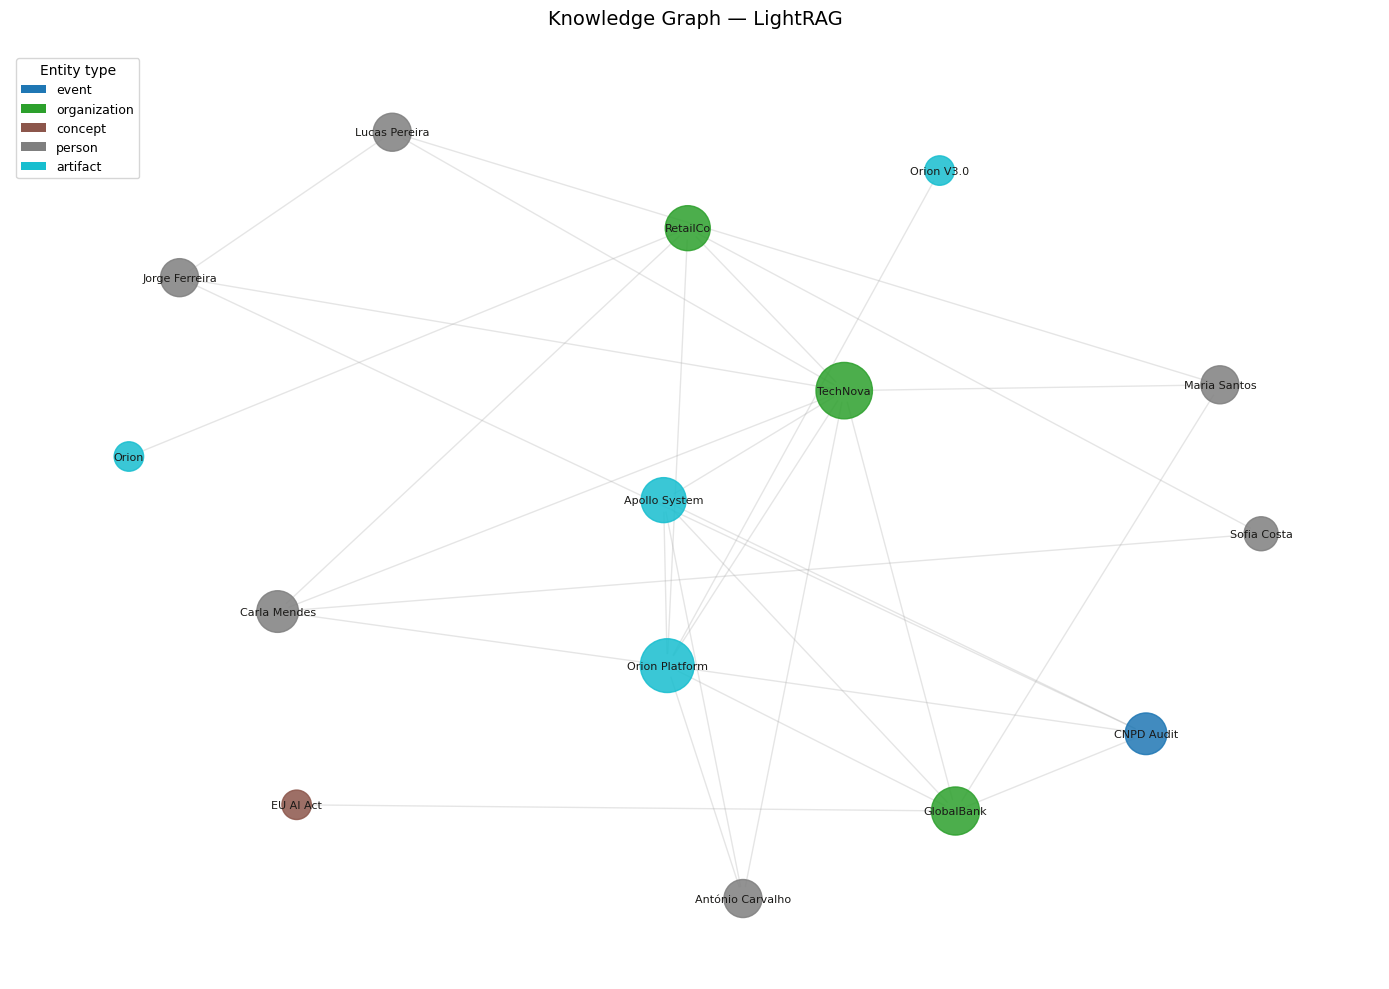

Graph saved to knowledge_graph.png


In [14]:
import matplotlib
import matplotlib.pyplot as plt
import networkx as nx
import os

graph_file = os.path.join(WORKING_DIR, "graph_chunk_entity_relation.graphml")

if not os.path.exists(graph_file):
    print("[WARN] Graph not found — run Section 3 first.")
else:
    G = nx.read_graphml(graph_file)
    
    # Limit to nodes with degree >= 2 to avoid cluttering the plot
    nodes_to_show = [n for n, d in G.degree() if d >= 2]
    G_sub = G.subgraph(nodes_to_show)
    
    print(f"Visualizing subgraph: {G_sub.number_of_nodes()} nodes, {G_sub.number_of_edges()} edges")
    
    plt.figure(figsize=(14, 10))
    plt.title("Knowledge Graph — LightRAG", fontsize=14, pad=20)
    plt.axis("off")
    
    # Layout
    pos = nx.spring_layout(G_sub, k=2.5, seed=42)
    
    # Node size proportional to degree
    degrees = dict(G_sub.degree())
    node_sizes = [300 + degrees[n] * 150 for n in G_sub.nodes()]
    
    # Color by entity type
    entity_types = [G_sub.nodes[n].get("entity_type", "UNKNOWN") for n in G_sub.nodes()]
    unique_types = list(set(entity_types))
    color_map = plt.cm.get_cmap("tab10", len(unique_types))
    type_to_color = {t: color_map(i) for i, t in enumerate(unique_types)}
    node_colors = [type_to_color[t] for t in entity_types]
    
    nx.draw_networkx_nodes(G_sub, pos, node_size=node_sizes,
                           node_color=node_colors, alpha=0.85)
    nx.draw_networkx_edges(G_sub, pos, alpha=0.3, edge_color="#aaaaaa",
                           arrows=True, arrowsize=12)
    nx.draw_networkx_labels(G_sub, pos, font_size=8, font_color="#1a1917")
    
    # Legend
    legend_elements = [
        matplotlib.patches.Patch(facecolor=type_to_color[t], label=t)
        for t in unique_types
    ]
    plt.legend(handles=legend_elements, loc="upper left", fontsize=9,
               framealpha=0.8, title="Entity type")
    
    plt.tight_layout()
    plt.savefig("knowledge_graph.png", dpi=150, bbox_inches="tight")
    plt.show()
    print("Graph saved to knowledge_graph.png")


---
## Section 9 — Try it on your corpus

Your turn. Adapt the questions to the corpus you loaded.  

### Mode guide

| Question | Recommended mode |
|---|---|
| "Who is responsible for X?" | `local` |
| "What is the relationship between A and B?" | `local` |
| "What happened on [date]?" | `local` |
| "What are the main themes?" | `global` |
| "What patterns emerge?" | `global` |
| "What is the overall state of X?" | `global` |
| "Explain X in detail" | `hybrid` |


In [52]:
# ── Your turn — define your questions here ────────────────────────────────────

MY_QUESTIONS = [
    ("local",  "<replace with a specific question about your corpus>"),
    ("global", "<replace with a thematic question about your corpus>"),
    ("hybrid", "<replace with a question needing both local and global context>"),
]

for mode, question in MY_QUESTIONS:
    if question.startswith("<"):
        print(f"[skip] Question not set for mode '{mode}' — edit the cell above.")
        continue
    print(f"\n{'='*60}")
    print(f"[{mode.upper()}] {question}")
    print(f"{'='*60}")
    result = await query(question, mode=mode)
    print(result)


[skip] Question not set for mode 'local' — edit the cell above.
[skip] Question not set for mode 'global' — edit the cell above.
[skip] Question not set for mode 'hybrid' — edit the cell above.


---
## Section 10 — Add documents to an existing graph

LightRAG supports incremental ingestion — you can add documents without rebuilding the graph from scratch.  
The system detects new entities and creates edges to existing ones.


In [32]:
# ── Additional document ────────────────────────────────────────────────────────
NEW_DOCUMENT = """
TechNova Press Release — February 2024

TechNova announces the appointment of Lucas Pereira as VP of Sales for the Iberian market.
Lucas Pereira joins from SAP Portugal, where he led enterprise sales for 8 years.
He will report directly to CEO Maria Santos and work alongside Jorge Ferreira on the
Spanish market expansion announced in Q4 2023.

Additionally, TechNova confirmed that RetailCo has expanded their Orion contract to include
the new ML pipeline module (Orion v3.0), scheduled for May 2024. This expansion was
negotiated by Carla Mendes and RetailCo IT Director Sofia Costa.
"""

print("Adding new document to the existing graph (Part B world memory — ainsert / FACT writes)...")
await rag.ainsert(NEW_DOCUMENT)
print("Document added — new entities and edges merged into the existing graph store.")

# Verify the new context is reachable
q_new = "What is Lucas Pereira's role and how does it connect to the Spanish expansion?"
print(f"\nTest: {q_new}")
print("-" * 60)
print(await query(q_new, mode="local"))


INFO: Created 1 duplicate document records with track_id: insert_20260421_204744_765f9d08
INFO: Preserving 3 failed document entries for manual review
INFO: No valid documents to process after consistency check
INFO: Enqueued document processing pipeline stopped


Adding new document to the existing graph (Part B world memory — ainsert / FACT writes)...
Document added — new entities and edges merged into the existing graph store.

Test: What is Lucas Pereira's role and how does it connect to the Spanish expansion?
------------------------------------------------------------


INFO:  == LLM cache == saving: local:keywords:9e4c3601a83aec7e8be4d9d132b76303
INFO: Query nodes: Lucas Pereira, Spanish expansion, Spain, Role responsibilities (top_k:40, cosine:0.2)
INFO: Local query: 32 entites, 45 relations
INFO: Raw search results: 32 entities, 45 relations, 0 vector chunks
INFO: After truncation: 32 entities, 45 relations
INFO: Selecting 2 from 2 entity-related chunks by vector similarity
INFO: Find no additional relations-related chunks from 45 relations
INFO: Round-robin merged chunks: 2 -> 2 (deduplicated 0)
INFO: Final context: 32 entities, 45 relations, 2 chunks
INFO: Final chunks S+F/O: E12/1 E27/2
INFO:  == LLM cache == saving: local:query:fb0bc3a8fabfcb491b06ce4e6c3a399e


## Lucas Pereira's Role and Connection to the Spanish Expansion

Lucas Pereira was appointed **VP of Sales for the Iberian Market** at TechNova. He joins from **SAP Portugal**, where he spent 8 years leading enterprise sales, bringing significant experience in the region.

### Reporting Structure

He reports directly to **CEO Maria Santos**, placing him at a senior level within TechNova's commercial leadership.

### Connection to the Spanish Market Expansion

The Spanish market expansion was **announced in Q4 2023** and is one of TechNova's key 2024 priorities, with a target of **3 enterprise clients**. Lucas Pereira works **alongside CTO Jorge Ferreira** on this initiative — Ferreira leads the technical and strategic side of the expansion, while Pereira's VP of Sales role positions him to drive the commercial side, including client acquisition in Spain.

TechNova also plans to **hire 5 engineers in Madrid** as part of this expansion, signalling a meaningful operational footprint being

---
## Next steps

### Production — five things nobody warns you about

1. **Routing wrong is worse than not routing** — log every decision; a mis-routed GraphRAG call burns tokens for nothing.
2. **Memory poisoning is real** — write user prefs **verbatim**; avoid interpreted summaries that drift.
3. **Rerankers are worth their latency** — a small rerank cost often pays back in less wrong context.
4. **Graph quality = extraction quality** — structured text yields dramatically better graphs.
5. **Observability beats accuracy** — trace routing + retrieval (LangSmith, Arize, …).

### Build 06 — from Colab to owned system

Harden **`.env`**, pin versions, move **`WORKING_DIR`** to durable storage, add evals on local vs global questions, then swap NetworkX for a hosted graph when scale requires it.

### For production (stack)

| Component | Dev | Production |
|---|---|---|
| Graph | NetworkX (RAM) | FalkorDB / Neo4j |
| Vector store | NanoVectorDB | Qdrant / Pinecone |
| LLM | gpt-4o-mini | gpt-4o / Claude Sonnet |
| Embedding | text-embedding-3-small | text-embedding-3-large |

### Switch to FalkorDB (one line)

```python
rag = LightRAG(
    working_dir=WORKING_DIR,
    graph_storage="FalkorDBStorage",          # ← only this changes
    vector_db_storage_cls_kwargs={
        "host": "localhost", "port": 6379
    },
    llm_model_func=gpt_4o_mini_complete,
    embedding_func=...,
)
```

### Take-home — no-code alternative

**Neo4j AuraDB Free** + **LLM Graph Builder** — upload PDFs, auto entities/relations, chat with citations: [neo4j.com/labs/genai-ecosystem/llm-graph-builder](https://neo4j.com/labs/genai-ecosystem/llm-graph-builder)

### References

- **LightRAG** — [github.com/HKUST-KnowComp/LightRAG](https://github.com/HKUST-KnowComp/LightRAG)
- **Microsoft GraphRAG** — [github.com/microsoft/graphrag](https://github.com/microsoft/graphrag)
- **LinkedIn / SIGIR 2024** — Xu et al.: *Retrieval-Augmented Generation with Knowledge Graphs for Customer Service QA*
- **Cedars-Sinai / Bioinformatics 2024** — Matsumoto et al.: *KRAGEN: a knowledge graph-enhanced RAG framework*

---

**Closing:** The graph does not replace RAG. It is what RAG becomes when the questions get serious.

*Rui Machado — [rui@maiolabs.ai](mailto:rui@maiolabs.ai) — [maiolabs.ai](https://maiolabs.ai)*
